**Mateusz Podporski, nr. alb. 152774**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from matplotlib.patches import Ellipse
import warnings

# Ignorowanie ostrzeżeń dla czytelności
warnings.filterwarnings('ignore')

### Zadanie 4: Algorytm K-means

Obliczenia dla syntetycznego zbioru danych `make_blobs` (300 próbek, 3 centra).
Celem jest podział danych na klastry i znalezienie optymalnej liczby $k$ metodą łokcia i silhouette.

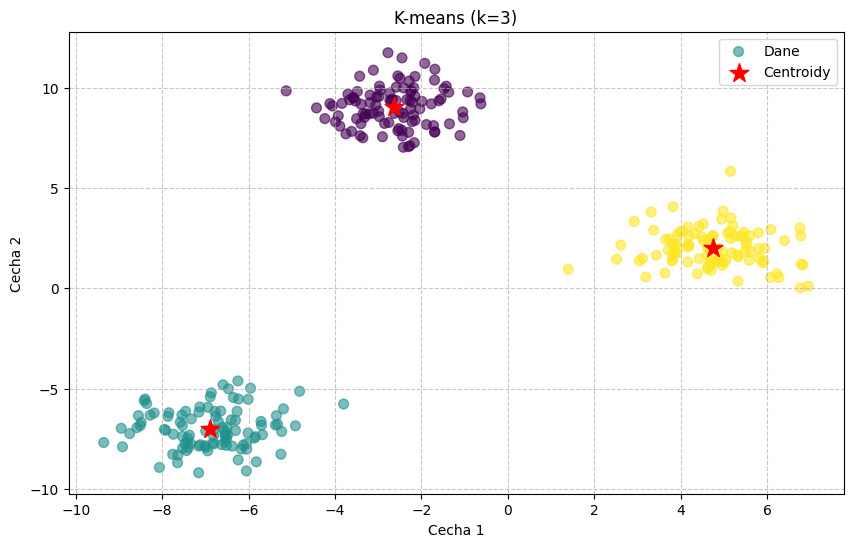

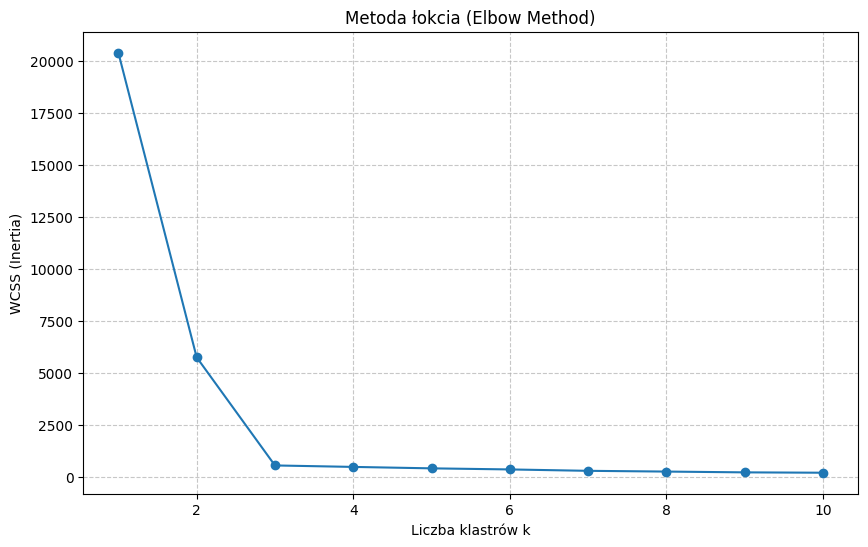

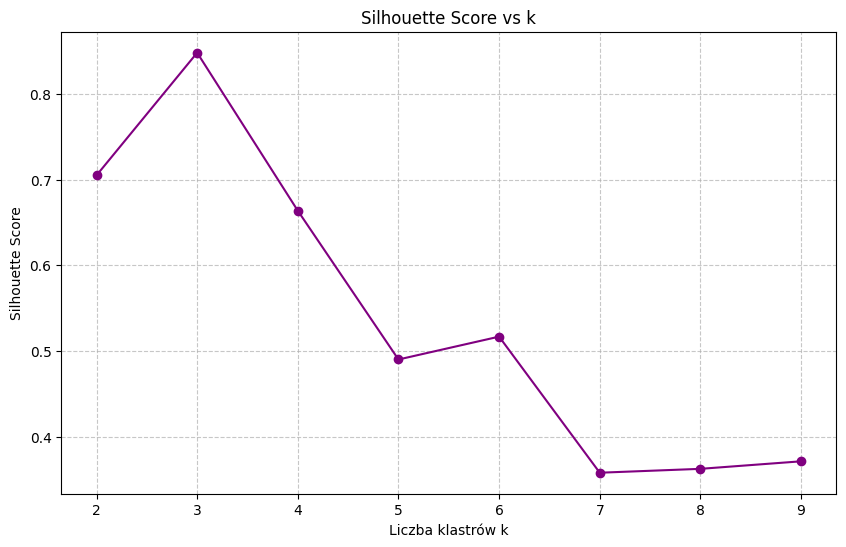

In [11]:
# 4a. Generowanie danych
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, random_state=42)

# 4b. Algorytm K-means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_blobs)

# 4c. Wizualizacja
plt.figure(figsize=(10, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_kmeans, s=50, cmap='viridis', alpha=0.6, label='Dane')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='*', label='Centroidy')
plt.title("K-means (k=3)")
plt.xlabel("Cecha 1")
plt.ylabel("Cecha 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4d. Metoda łokcia (Elbow Method)
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_blobs)
    wcss.append(kmeans_temp.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o')
plt.title("Metoda łokcia (Elbow Method)")
plt.xlabel("Liczba klastrów k")
plt.ylabel("WCSS (Inertia)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show() # Wniosek: optymalne k=3

# 4e. Silhouette Score
silhouette_scores = []
k_range_sil = range(2, 10)
for k in k_range_sil:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_temp.fit_predict(X_blobs)
    silhouette_avg = silhouette_score(X_blobs, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(10, 6))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='purple')
plt.title("Silhouette Score vs k")
plt.xlabel("Liczba klastrów k")
plt.ylabel("Silhouette Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Zadanie 5: Gaussian Mixture Models (GMM)

Analiza na zbiorze `make_blobs` przy użyciu modelu mieszanin gaussowskich.
Weryfikacja dopasowania za pomocą wykresów elips kowariancji oraz kryterium BIC.

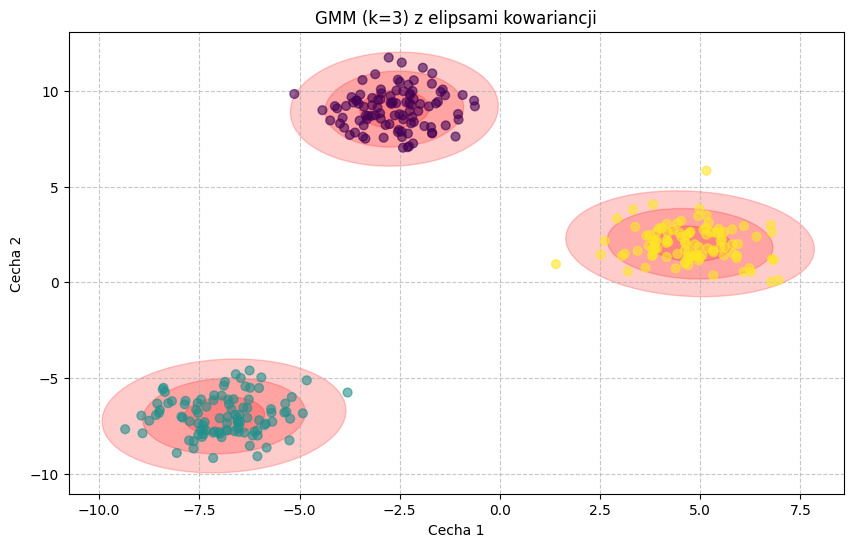

Przykładowe prawdopodobieństwa przynależności dla pierwszych 5 punktów:
[[0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


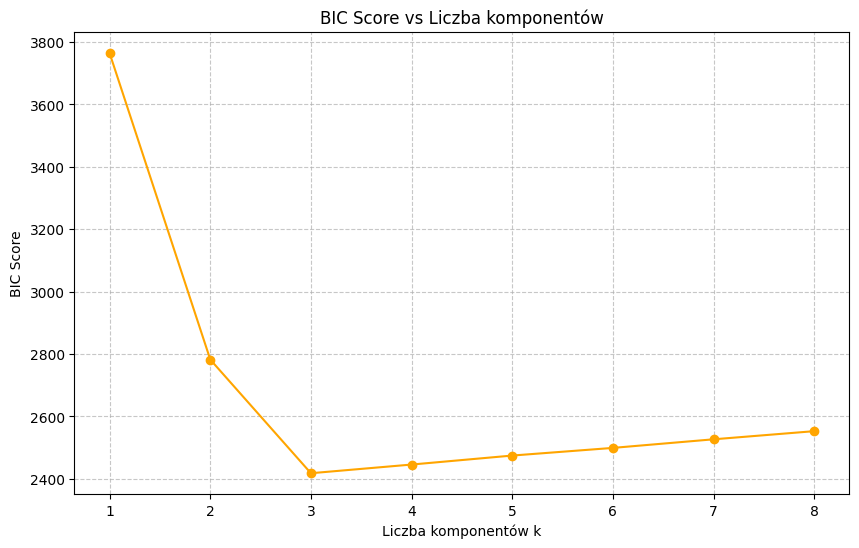

In [12]:
# 5b. GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_blobs)
y_gmm = gmm.predict(X_blobs)

# 5c. Wizualizacja z elipsami
def draw_ellipse(position, covariance, ax=None, **kwargs):
    ax = ax or plt.gca()
    # Jeśli kowariancja jest diagonalna lub sferyczna
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        # Dla covariance_type='spherical' lub 'diag' (uproszczenie pod standardowe 'full')
        # Tutaj zakładamy 'full' domyślnie w GaussianMixture
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, width=nsig * width, height=nsig * height, angle=angle, **kwargs))

plt.figure(figsize=(10, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_gmm, s=40, cmap='viridis', zorder=2, alpha=0.6)
ax = plt.gca()
for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
    draw_ellipse(pos, covar, alpha=0.2, color='red') # Elipsy

plt.title("GMM (k=3) z elipsami kowariancji")
plt.xlabel("Cecha 1")
plt.ylabel("Cecha 2")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5d. Twarde vs Miękkie przypisanie
probs = gmm.predict_proba(X_blobs)
print("Przykładowe prawdopodobieństwa przynależności dla pierwszych 5 punktów:")
print(np.round(probs[:5], 3))

# 5e. Kryterium BIC
bic_scores = []
k_range_bic = range(1, 9)
for k in k_range_bic:
    gmm_temp = GaussianMixture(n_components=k, random_state=42)
    gmm_temp.fit(X_blobs)
    bic_scores.append(gmm_temp.bic(X_blobs))

plt.figure(figsize=(10, 6))
plt.plot(k_range_bic, bic_scores, marker='o', color='orange')
plt.title("BIC Score vs Liczba komponentów")
plt.xlabel("Liczba komponentów k")
plt.ylabel("BIC Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Zadanie 6: Algorytm DBSCAN

Analiza działania algorytmu DBSCAN na zbiorach o nietypowych kształtach (`make_moons`, `make_circles`) oraz porównanie z K-means na `make_blobs`.
Dobór parametru `eps` i `min_samples`.

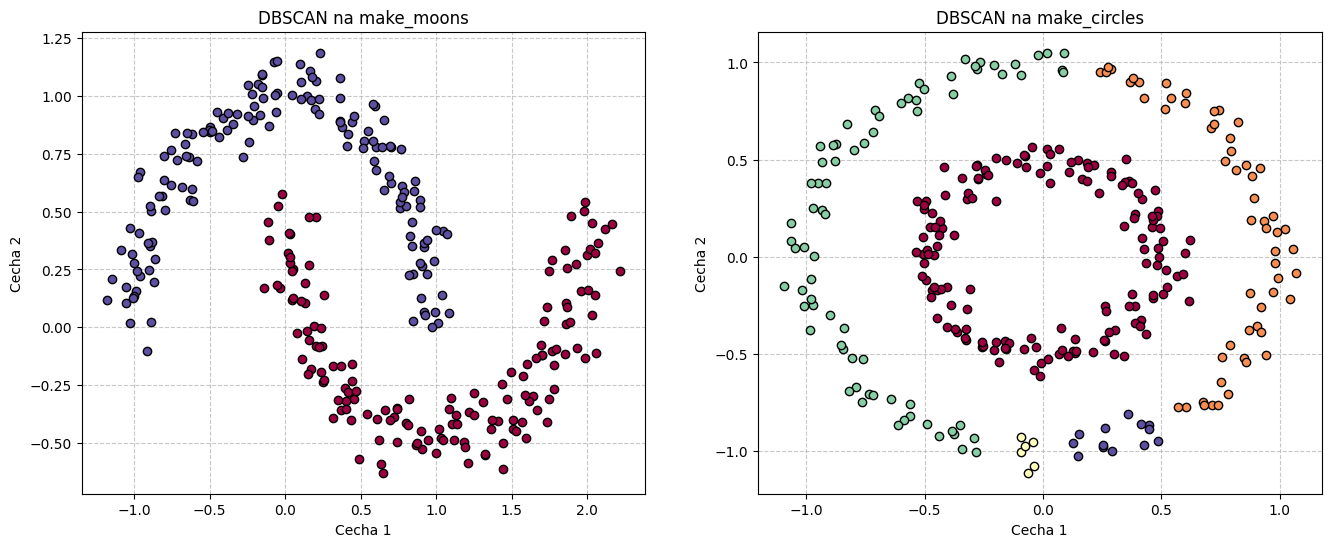

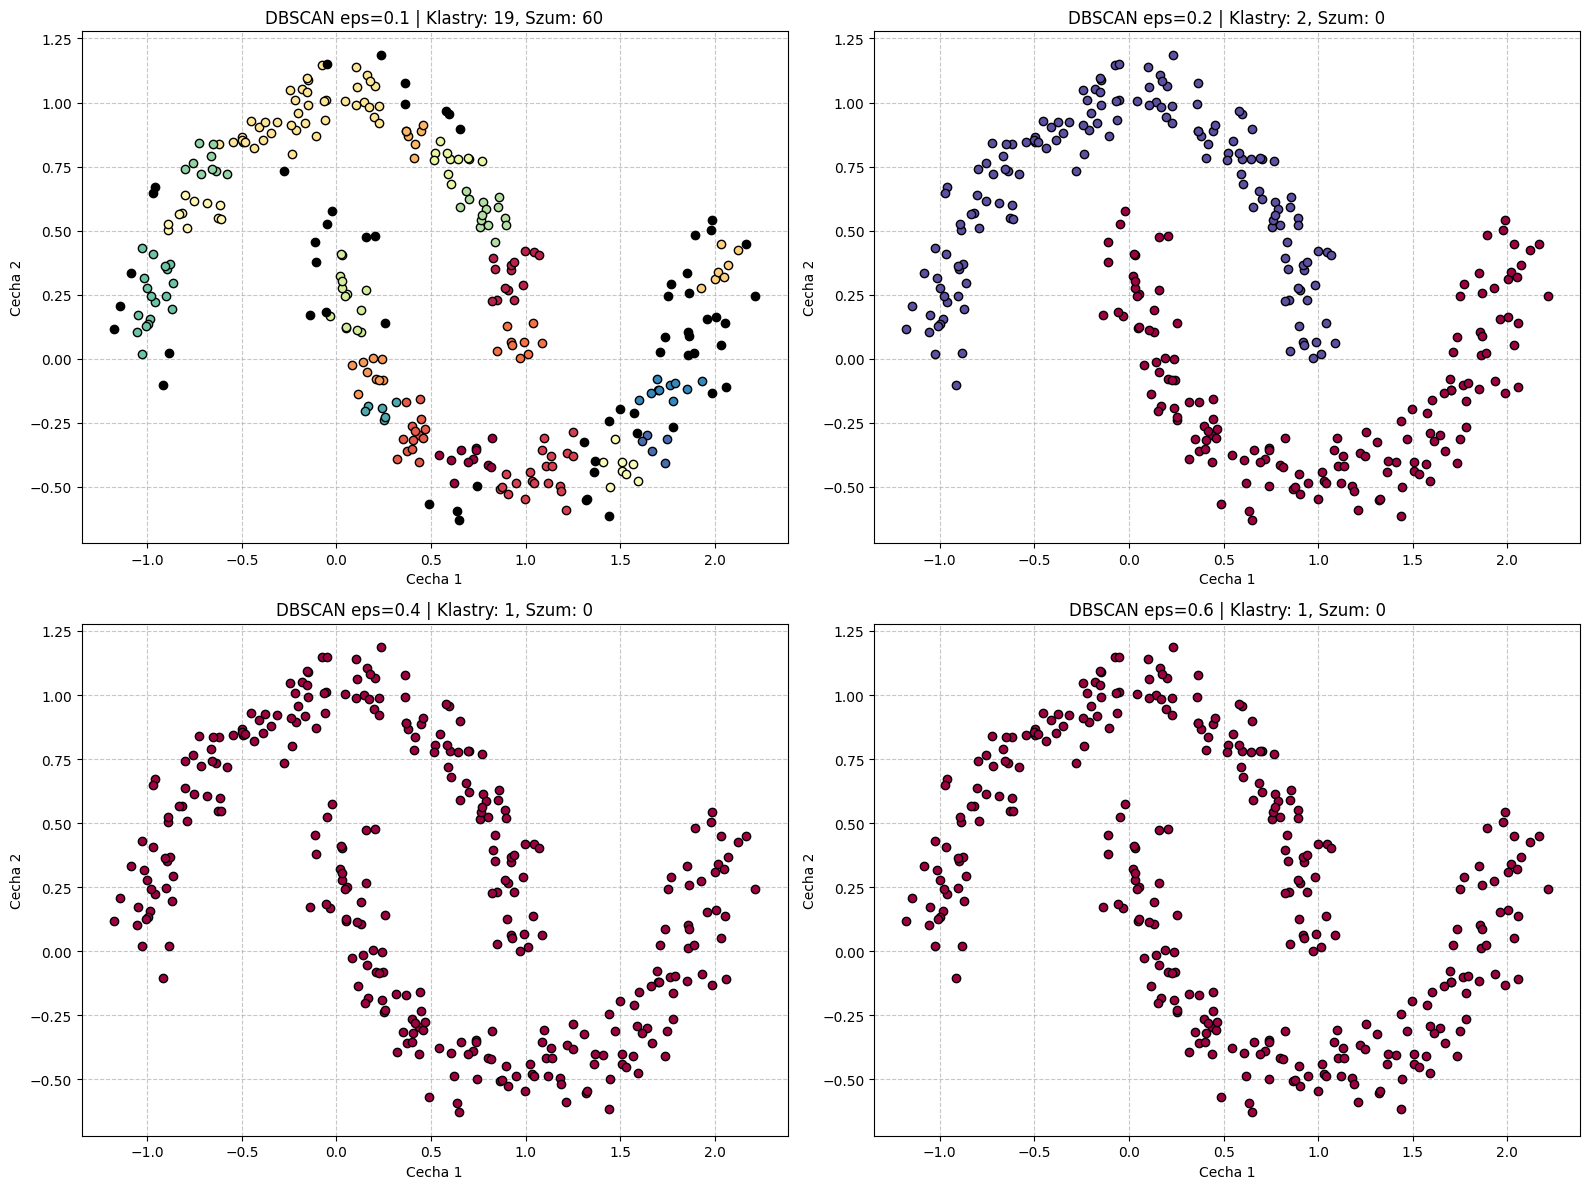

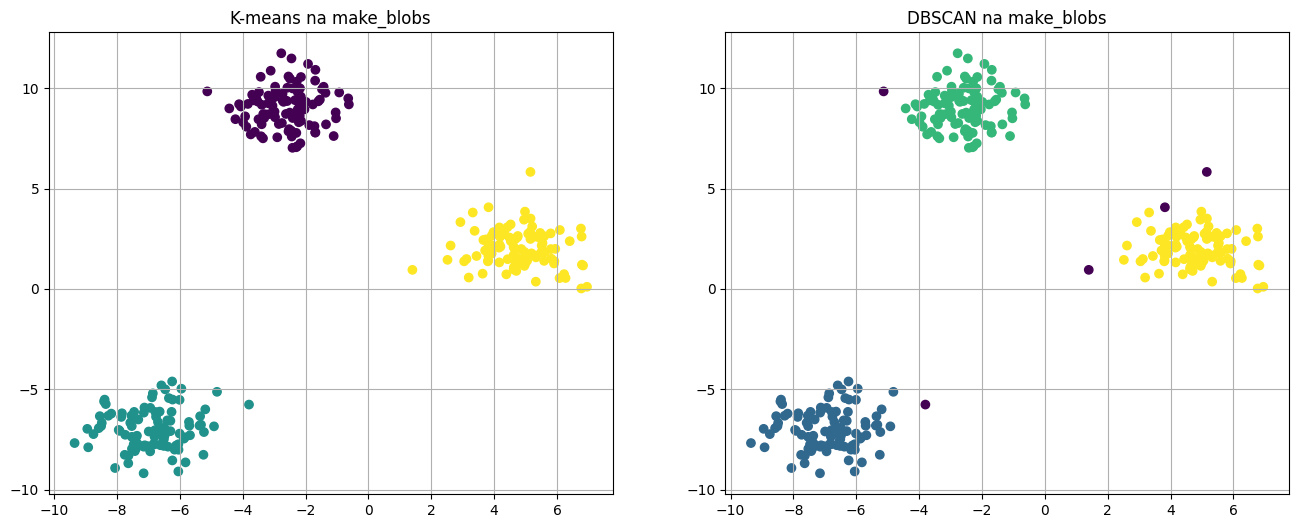

In [13]:
# 6a. Generowanie danych
X_moons, _ = make_moons(n_samples=300, noise=0.08, random_state=42)
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# 6b. DBSCAN
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
y_moons = dbscan_moons.fit_predict(X_moons)

dbscan_circles = DBSCAN(eps=0.15, min_samples=5)
y_circles = dbscan_circles.fit_predict(X_circles)

# 6c. Wizualizacja
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Helper do rysowania
def plot_dbscan(X, labels, ax, title):
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1] # Czarny dla szumu
        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=6)
    ax.set_title(title)
    ax.set_xlabel("Cecha 1")
    ax.set_ylabel("Cecha 2")
    ax.grid(True, linestyle='--', alpha=0.7)

plot_dbscan(X_moons, y_moons, ax[0], "DBSCAN na make_moons")
plot_dbscan(X_circles, y_circles, ax[1], "DBSCAN na make_circles")
plt.show()

# 6d. Wpływ parametru eps
eps_values = [0.1, 0.2, 0.4, 0.6]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, eps in enumerate(eps_values):
    # Używamy moons jako przykładu
    db = DBSCAN(eps=eps, min_samples=5).fit(X_moons)
    y_db = db.labels_
    n_clusters = len(set(y_db)) - (1 if -1 in y_db else 0)
    n_noise = list(y_db).count(-1)
    
    plot_dbscan(X_moons, y_db, axes[i], f"DBSCAN eps={eps} | Klastry: {n_clusters}, Szum: {n_noise}")

plt.tight_layout()
plt.show()

# 6e. DBSCAN vs K-means na blobs
dbscan_blobs = DBSCAN(eps=1.0, min_samples=5) 
y_db_blobs = dbscan_blobs.fit_predict(X_blobs)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_kmeans, cmap='viridis')
ax[0].set_title("K-means na make_blobs")
ax[0].grid(True)

ax[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_db_blobs, cmap='viridis')
ax[1].set_title("DBSCAN na make_blobs")
ax[1].grid(True)

plt.show()

### Zadanie 7: Miary jakości klastrów

Porównanie wydajności algorytmów K-means, GMM i DBSCAN na zbiorze `make_blobs` przy użyciu miar wewnętrznych i zewnętrznych.

In [14]:
# Funkcja do liczenia metryk
def calculate_metrics(X, labels_pred, labels_true):
    # Jeśli tylko jeden klaster lub same szumy
    if len(set(labels_pred)) < 2:
        return np.nan, np.nan, np.nan, np.nan, np.nan
        
    sil = silhouette_score(X, labels_pred)
    db = davies_bouldin_score(X, labels_pred)
    ch = calinski_harabasz_score(X, labels_pred)
    ari = adjusted_rand_score(labels_true, labels_pred)
    nmi = normalized_mutual_info_score(labels_true, labels_pred)
    return sil, db, ch, ari, nmi

metrics_kmeans = calculate_metrics(X_blobs, y_kmeans, y_blobs)
metrics_gmm = calculate_metrics(X_blobs, y_gmm, y_blobs)
metrics_dbscan = calculate_metrics(X_blobs, y_db_blobs, y_blobs)

results = pd.DataFrame([metrics_kmeans, metrics_gmm, metrics_dbscan], 
                       columns=["Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "ARI", "NMI"],
                       index=["K-means", "GMM", "DBSCAN"])

print("Tabela miar jakości klastrów (make_blobs):")
results.round(4)

Tabela miar jakości klastrów (make_blobs):


,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
K-means,0.8480,0.2123,5196.2951,1.0000,1.0000
GMM,0.8480,0.2123,5196.2951,1.0000,1.0000
DBSCAN,0.7888,1.1896,2634.3460,0.9748,0.9567


## Podsumowanie i wnioski

### Wnioski dotyczące algorytmów

1.  **K-means**:
    *   Najlepiej sprawdza się dla klastrów o kształcie sferycznym i podobnej wielkości.
    *   Metoda łokcia i silhouette score poprawnie wskazały $k=3$ jako optymalną liczbę klastrów dla zbioru `make_blobs`.
    *   Jest szybki i efektywny obliczeniowo.

2.  **GMM (Gaussian Mixture Models)**:
    *   Pozwala na modelowanie klastrów o kształcie elips (dzięki macierzy kowariancji), co daje większą elastyczność niż K-means.
    *   Kryterium BIC wyraźnie wskazało optymalną liczbę komponentów.
    *   Umożliwia "miękkie" przypisanie (prawdopodobieństwa), co jest kluczowe w modelach probabilistycznych.

3.  **DBSCAN**:
    *   Bezkonkurencyjny w wykrywaniu klastrów o nieregularnych kształtach (`make_moons`, `make_circles`), gdzie K-means i GMM zawodzą.
    *   Wymaga starannego doboru parametrów `eps` i `min_samples`. Zbyt małe `eps` powoduje zaklasyfikowanie dużej ilości danych jako szum (-1).
    *   Automatycznie wykrywa liczbę klastrów i radzi sobie z szumem.

### Porównanie miar jakości
Na zbiorze prostym (`make_blobs`), wszystkie algorytmy osiągnęły wysokie wyniki miar zewnętrznych (ARI, NMI bliskie 1), co świadczy o poprawnym odwzorowaniu prawdziwych etykiet. Miary wewnętrzne (Silhouette, Davies-Bouldin) również faworyzują wyraźnie odseparowane klastry. Dla zbiorów złożonych (moons, circles) miary oparte na odległości (jak Silhouette) mogą być mylące dla algorytmów gęstościowych jak DBSCAN.